In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing import image_dataset_from_directory
from sklearn.utils import class_weight
import matplotlib.pyplot as plt
import wandb


In [2]:
# 1. Initialize WandB
wandb.init(
    project="Saka-RHD-Detection",
    config={
        "architecture": "MobileNetV2",
        "dataset": "PhysioNet-CirCOR-Hybrid",
        "learning_rate": 0.0005,
        "epochs": 30,
        "batch_size": 32,
        "img_size": (128, 128)
    }
)
config = wandb.config


wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /Users/sola/.netrc
wandb: Currently logged in as: e-githinji1 (e-githinji1-african-leadership-group) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [5]:
# 2. Paths
DATA_PATH = "../data/processed/heart_grades_classified"
MODEL_SAVE_PATH = "../exported_models/saka_v1.h5"

In [6]:
# 3. Load Datasets - Train/Val/Test Split (70/15/15)


# First, get the full dataset to split it manually
full_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_PATH,
    seed=123,
    image_size=config.img_size,
    batch_size=config.batch_size,
    label_mode='int'
)

# Get class names BEFORE any transformations
class_names = full_ds.class_names
print(f"Classes found: {class_names}")

# Calculate dataset sizes
dataset_size = tf.data.experimental.cardinality(full_ds).numpy()
train_size = int(0.7 * dataset_size)
val_size = int(0.15 * dataset_size)
test_size = dataset_size - train_size - val_size

print(f"Total batches: {dataset_size}")
print(f"Train batches: {train_size}")
print(f"Val batches: {val_size}")
print(f"Test batches: {test_size}")

# Split the dataset
train_ds = full_ds.take(train_size)
remaining_ds = full_ds.skip(train_size)
val_ds = remaining_ds.take(val_size)
test_ds = remaining_ds.skip(val_size)

# Optional: Cache and prefetch for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

# class_names is already defined above, so no need to access from train_ds
print(f"Training with classes: {class_names}")
print(f"Number of classes: {len(class_names)}")

Found 29431 files belonging to 4 classes.
Classes found: ['Grade_0', 'Grade_1', 'Grade_2', 'Grade_3']
Total batches: 920
Train batches: 644
Val batches: 138
Test batches: 138
Training with classes: ['Grade_0', 'Grade_1', 'Grade_2', 'Grade_3']
Number of classes: 4


In [17]:
# 4. Handle Class Imbalance - Memory Efficient Version
import numpy as np
from sklearn.utils import class_weight

# Get labels without loading all data into memory
def get_all_labels(dataset):
    labels = []
    for _, y in dataset:
        labels.extend(y.numpy().tolist())
    return np.array(labels)

y_train = get_all_labels(train_ds)
unique_classes = np.unique(y_train)
print(f"Unique classes in training: {unique_classes}")
print(f"Class distribution: {np.bincount(y_train.astype(int))}")

# Calculate class weights
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=unique_classes,
    y=y_train
)
class_weights_dict = dict(enumerate(class_weights))
print(f"Calculated Class Weights: {class_weights_dict}")

Unique classes in training: [0 1 2 3]
Class distribution: [16156  2219   835  1398]
Calculated Class Weights: {0: 0.3188908145580589, 1: 2.321766561514196, 2: 6.170059880239521, 3: 3.6852646638054365}


2026-06-21 21:14:11.158407: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [8]:
# 4. Handle Class Imbalance

# calculate weights so the model pays 20x more attention to Grade 2.
y_train = np.concatenate([y for x, y in train_ds], axis=0)
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(enumerate(weights))
print(f"Calculated Class Weights: {class_weights_dict}")

# 5. Data Augmentation (Crucial for the minority classes)
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])


Calculated Class Weights: {0: 0.3188908145580589, 1: 2.321766561514196, 2: 6.170059880239521, 3: 3.6852646638054365}


2026-06-21 20:27:59.378537: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [9]:
import tensorflow as tf

# Constants
BATCH_SIZE = config.batch_size
IMG_SIZE = config.img_size
AUTOTUNE = tf.data.AUTOTUNE

# 1. Load dataset with proper configuration
full_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_PATH,
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,  # Consistent batch size
    label_mode='int'
)

# Store class names
class_names = full_ds.class_names
num_classes = len(class_names)
print(f"Classes: {class_names}")

# 2. Split the dataset
dataset_size = tf.data.experimental.cardinality(full_ds).numpy()
train_size = int(0.7 * dataset_size)
val_size = int(0.15 * dataset_size)
test_size = dataset_size - train_size - val_size

print(f"Dataset sizes: Train={train_size}, Val={val_size}, Test={test_size}")

# 3. Perform the split
train_ds = full_ds.take(train_size)
remaining_ds = full_ds.skip(train_size)
val_ds = remaining_ds.take(val_size)
test_ds = remaining_ds.skip(val_size)

# 4. OPTIONAL: Reset datasets to ensure clean state
train_ds = train_ds.unbatch().batch(BATCH_SIZE)
val_ds = val_ds.unbatch().batch(BATCH_SIZE)
test_ds = test_ds.unbatch().batch(BATCH_SIZE)

# 5. Optimize datasets
train_ds = train_ds.cache().shuffle(1000, seed=123).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

# 6. Verify dataset shapes
for images, labels in train_ds.take(1):
    print(f"Train batch - Images: {images.shape}, Labels: {labels.shape}")
    print(f"Sample labels: {labels[:5].numpy()}")

# 7. Build the model (without input_shape in layers)
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(*IMG_SIZE, 3)),  # Input layer
    tf.keras.layers.Rescaling(1./255),
    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(128, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 8. Train
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

# 9. Test
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Accuracy: {test_acc:.4f}")

Found 29431 files belonging to 4 classes.
Classes: ['Grade_0', 'Grade_1', 'Grade_2', 'Grade_3']
Dataset sizes: Train=644, Val=138, Test=138
Train batch - Images: (32, 128, 128, 3), Labels: (32,)
Sample labels: [3 0 3 3 0]
Epoch 1/10


2026-06-21 20:28:43.191916: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


    644/Unknown 72s 111ms/step - accuracy: 0.7801 - loss: 0.7634

2026-06-21 20:29:55.088288: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
/Users/sola/miniforge3/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


644/644 ━━━━━━━━━━━━━━━━━━━━ 78s 120ms/step - accuracy: 0.7843 - loss: 0.7216 - val_accuracy: 0.7856 - val_loss: 0.6477
Epoch 2/10
  1/644 ━━━━━━━━━━━━━━━━━━━━ 1:23 130ms/step - accuracy: 0.7500 - loss: 0.8757

...

2026-06-21 20:44:50.609258: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


644/644 ━━━━━━━━━━━━━━━━━━━━ 113s 176ms/step - accuracy: 0.8060 - loss: 0.5892 - val_accuracy: 0.8041 - val_loss: 0.6025


2026-06-21 20:44:57.540148: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


138/138 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step - accuracy: 0.8064 - loss: 0.6009
Test Accuracy: 0.8064


2026-06-21 20:45:07.409023: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


Error in callback <bound method _WandbInit._pre_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x35e9b3500>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 4460ce060, raw_cell="# ===== CELL 1: Disable W&B and setup =====
import.." transformed_cell="# ===== CELL 1: Disable W&B and setup =====
import.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/sola/capstone/ai_model/src/model_training.ipynb#X30sZmlsZQ%3D%3D>,),kwargs {}:


ConnectionResetError: Connection lost

Found 29431 files belonging to 4 classes.
Using 20602 files for training.
Classes: ['Grade_0', 'Grade_1', 'Grade_2', 'Grade_3']
Splits - Train: 450, Val: 96, Test: 98
Class Weights: {0: 0.31869688385269124, 1: 2.315112540192926, 2: 6.581352833638026, 3: 3.592814371257485}


2026-06-21 21:28:03.621708: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Model: "sequential_13"

...

 Non-trainable params: 0 (0.00 B)


🚀 Starting Training...
Epoch 1/30


ValueError: Exception encountered when calling Sequential.call().

[1mInvalid input shape for input Tensor("data:0", shape=(None, None, 128, 128, 3), dtype=float32) with name 'keras_tensor_736' and path ''. Expected shape (None, 128, 128, 3), but input has incompatible shape (None, None, 128, 128, 3)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(None, None, 128, 128, 3), dtype=float32)
  • training=True
  • mask=None
  • kwargs=<class 'inspect._empty'>

Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x35e9b3500>> (for post_run_cell), with arguments args (<ExecutionResult object at 4460cfda0, execution_count=22 error_before_exec=None error_in_exec=Exception encountered when calling Sequential.call().

Invalid input shape for input Tensor("data:0", shape=(None, None, 128, 128, 3), dtype=float32) with name 'keras_tensor_736' and path ''. Expected shape (None, 128, 128, 3), but input has incompatible shape (None, None, 128, 128, 3)

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(None, None, 128, 128, 3), dtype=float32)
  • training=True
  • mask=None
  • kwargs=<class 'inspect._empty'> info=<ExecutionInfo object at 4460ce060, raw_cell="# ===== CELL 1: Disable W&B and setup =====
import.." transformed_cell="# ===== CELL 1: Disable W&B and setup =====
import.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/sola/capsto

ConnectionResetError: Connection lost

In [10]:
# 6. Model using MobileNetV2 Transfer Learning

base_model = MobileNetV2(input_shape=(128, 128, 3), include_top=False, weights='imagenet')
base_model.trainable = False

model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),
    data_augmentation,
    layers.Lambda(lambda x: tf.keras.applications.mobilenet_v2.preprocess_input(x)),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(4, activation='softmax')
])

model.compile(
    optimizer=optimizers.Adam(learning_rate=config.learning_rate),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.SparseTopKCategoricalAccuracy(k=2, name='top_2_accuracy')]
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 6s 1us/step


In [11]:
# 7. Training
print("Training started")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=config.epochs,
    class_weight=class_weights_dict,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
        tf.keras.callbacks.ModelCheckpoint(MODEL_SAVE_PATH, save_best_only=True)
    ]
)


Training started
Epoch 1/30
    644/Unknown 53s 80ms/step - accuracy: 0.3094 - loss: 1.5322 - top_2_accuracy: 0.5825

2026-06-21 20:46:22.161798: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
2026-06-21 20:46:34.138476: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


644/644 ━━━━━━━━━━━━━━━━━━━━ 65s 99ms/step - accuracy: 0.3199 - loss: 1.4332 - top_2_accuracy: 0.5758 - val_accuracy: 0.6918 - val_loss: 1.2653 - val_top_2_accuracy: 0.8392
Epoch 2/30
644/644 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.3462 - loss: 1.3648 - top_2_accuracy: 0.5863

2026-06-21 20:47:32.775042: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


644/644 ━━━━━━━━━━━━━━━━━━━━ 70s 109ms/step - accuracy: 0.3759 - loss: 1.3598 - top_2_accuracy: 0.5942 - val_accuracy: 0.4332 - val_loss: 1.3292 - val_top_2_accuracy: 0.5858
Epoch 3/30
  1/644 ━━━━━━━━━━━━━━━━━━━━ 1:48 169ms/step - accuracy: 0.4375 - loss: 1.3158 - top_2_accuracy: 0.5938

...

2026-06-21 20:59:27.066746: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


644/644 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.4405 - loss: 1.3096 - top_2_accuracy: 0.6741

2026-06-21 21:00:27.510480: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


644/644 ━━━━━━━━━━━━━━━━━━━━ 72s 111ms/step - accuracy: 0.4623 - loss: 1.3077 - top_2_accuracy: 0.6853 - val_accuracy: 0.7622 - val_loss: 1.1593 - val_top_2_accuracy: 0.8748


2026-06-21 21:00:38.806597: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


2026-06-21 21:07:38.358296: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-06-21 21:07:39.189379: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Training set distribution:
  Grade_0: 16156
  Grade_1: 2219
  Grade_2: 835
  Grade_3: 1398


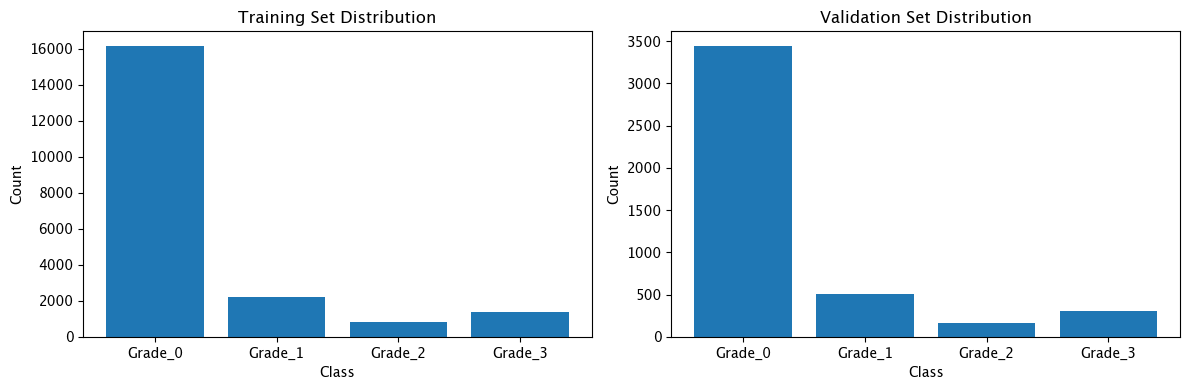

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Check if your dataset is balanced
def check_class_distribution(dataset, class_names):
    class_counts = {name: 0 for name in class_names}
    for images, labels in dataset.unbatch():
        class_name = class_names[labels.numpy()]
        class_counts[class_name] += 1
    return class_counts

train_counts = check_class_distribution(train_ds, class_names)
val_counts = check_class_distribution(val_ds, class_names)

print("Training set distribution:")
for cls, count in train_counts.items():
    print(f"  {cls}: {count}")
    
# Visualize
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(class_names, [train_counts[c] for c in class_names])
ax[0].set_title('Training Set Distribution')
ax[0].set_xlabel('Class')
ax[0].set_ylabel('Count')

ax[1].bar(class_names, [val_counts[c] for c in class_names])
ax[1].set_title('Validation Set Distribution')
ax[1].set_xlabel('Class')
ax[1].set_ylabel('Count')
plt.tight_layout()
plt.show()

In [12]:
# 8. Evaluation & Final Logging
print(" Training Finished. Evaluating...")
loss, acc, top2 = model.evaluate(val_ds)
wandb.log({"final_val_accuracy": acc, "final_val_loss": loss})

 Training Finished. Evaluating...
138/138 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step - accuracy: 0.7086 - loss: 1.0772 - top_2_accuracy: 0.8030


2026-06-21 21:03:49.667903: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


In [15]:
# 9. Save as TFLite for the Mobile App / Edge
import os

# Use model.export() to create a SavedModel for TFLite/TFServing
saved_model_path = "../exported_models/saka_v1_saved_model"
os.makedirs(saved_model_path, exist_ok=True)

# Export as SavedModel
model.export(saved_model_path)

# Convert from SavedModel
converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_path)

# Optional: Optimize for mobile
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Convert to TFLite
tflite_model = converter.convert()

# Save TFLite model
tflite_path = "../exported_models/saka_v1.tflite"
with open(tflite_path, "wb") as f:
    f.write(tflite_model)

print(f"SavedModel exported to {saved_model_path}")
print(f"TFLite version saved to {tflite_path}")
wandb.finish()

INFO:tensorflow:Assets written to: ../exported_models/saka_v1_saved_model/assets


INFO:tensorflow:Assets written to: ../exported_models/saka_v1_saved_model/assets


Saved artifact at '../exported_models/saka_v1_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='keras_tensor_178')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  18618402192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  18618402384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  18618402960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  18614010704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  18645285776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  18645270800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  18614012624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  18618403152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  18645286736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  14510682192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  18645286352: TensorSpec(shap

W0000 00:00:1782068726.802083 3534368 tf_tfl_flatbuffer_helpers.cc:390] Ignored output_format.
W0000 00:00:1782068726.802701 3534368 tf_tfl_flatbuffer_helpers.cc:393] Ignored drop_control_dependency.
2026-06-21 21:05:26.812005: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: ../exported_models/saka_v1_saved_model
2026-06-21 21:05:26.817060: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-06-21 21:05:26.817069: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: ../exported_models/saka_v1_saved_model
2026-06-21 21:05:26.929749: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:388] MLIR V1 optimization pass is not enabled
2026-06-21 21:05:26.941730: I tensorflow/cc/saved_model/loader.cc:234] Restoring SavedModel bundle.
2026-06-21 21:05:27.304575: I tensorflow/cc/saved_model/loader.cc:218] Running initialization op on SavedModel bundle at path: ../exported_models/saka_v1_saved_model

ConverterError: Could not translate MLIR to FlatBuffer.<unknown>:0: error: loc(callsite(callsite(fused["StatelessRandomGetKeyCounter:", "sequential_3_1/sequential_1_1/random_flip_1/stateless_random_uniform/StatelessRandomGetKeyCounter@__inference___call___105481"] at fused["StatefulPartitionedCall:", "StatefulPartitionedCall@__inference_signature_wrapper___call___106560"]) at fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"])): 'tf.StatelessRandomGetKeyCounter' op is neither a custom op nor a flex op
<unknown>:0: note: loc(fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"]): called from
<unknown>:0: note: loc(callsite(callsite(fused["StatelessRandomGetKeyCounter:", "sequential_3_1/sequential_1_1/random_flip_1/stateless_random_uniform/StatelessRandomGetKeyCounter@__inference___call___105481"] at fused["StatefulPartitionedCall:", "StatefulPartitionedCall@__inference_signature_wrapper___call___106560"]) at fused["StatefulPartitionedCall:", "StatefulPartitionedCall

In [25]:
# ===== COMPLETE W&B CLEANUP =====
import os
import sys
import wandb

# 1. Disable W&B completely
os.environ['WANDB_DISABLED'] = 'true'
os.environ['WANDB_MODE'] = 'disabled'
os.environ['WANDB_SILENT'] = 'true'

# 2. Finish any existing wandb runs
try:
    wandb.finish()
except:
    pass

# 3. Unload wandb from memory
try:
    if 'wandb' in sys.modules:
        del sys.modules['wandb']
except:
    pass

# 4. Set notebook hooks to ignore
try:
    from wandb.integration import notebook
    notebook.unpatch()  # Remove notebook hooks
except:
    pass

print("✅ W&B completely disabled")

# Now import your other libraries
import tensorflow as tf
import numpy as np
from sklearn.utils import class_weight
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import seaborn as sns

Error in callback <bound method _WandbInit._pre_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x35e9b3500>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 395bf0830, raw_cell="# ===== COMPLETE W&B CLEANUP =====
import os
impor.." transformed_cell="# ===== COMPLETE W&B CLEANUP =====
import os
impor.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/sola/capstone/ai_model/src/model_training.ipynb#X32sZmlsZQ%3D%3D>,),kwargs {}:


ConnectionResetError: Connection lost

✅ W&B completely disabled
Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x35e9b3500>> (for post_run_cell), with arguments args (<ExecutionResult object at 395bf3680, execution_count=25 error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 395bf0830, raw_cell="# ===== COMPLETE W&B CLEANUP =====
import os
impor.." transformed_cell="# ===== COMPLETE W&B CLEANUP =====
import os
impor.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/sola/capstone/ai_model/src/model_training.ipynb#X32sZmlsZQ%3D%3D> result=None>,),kwargs {}:


ConnectionResetError: Connection lost

In [ ]:
# CELL 1: COMPLETE W&B PURGE
import os
import sys
import subprocess

# Kill any wandb processes
try:
    subprocess.run(['pkill', '-9', '-f', 'wandb'], capture_output=True)
except:
    pass

# Remove wandb from environment
os.environ.pop('WANDB_API_KEY', None)
os.environ.pop('WANDB_ENTITY', None)
os.environ.pop('WANDB_PROJECT', None)

# Set to disabled
os.environ['WANDB_DISABLED'] = 'true'
os.environ['WANDB_MODE'] = 'disabled'
os.environ['WANDB_SILENT'] = 'true'
os.environ['WANDB_AGENT_DISABLE_FLAG'] = 'true'
os.environ['WANDB_NOTEBOOK'] = 'false'

# Remove wandb from sys.modules
wandb_modules = [m for m in sys.modules.keys() if 'wandb' in m]
for m in wandb_modules:
    del sys.modules[m]

# Try to import and immediately disable
try:
    import wandb
    wandb.init(mode="disabled")
    wandb.finish()
except:
    pass

print("✅ W&B completely purged from this session")

In [31]:
#!/usr/bin/env python3
"""
Clean training script - No W&B dependencies
Run with: python train_clean.py
"""

import os
import sys

# Force disable wandb before anything else
os.environ['WANDB_DISABLED'] = 'true'
os.environ['WANDB_MODE'] = 'disabled'
os.environ['WANDB_SILENT'] = 'true'

# Now import everything
import tensorflow as tf
import numpy as np
from sklearn.utils import class_weight
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from datetime import datetime

# Configuration
class Config:
    img_size = (224, 224)
    batch_size = 32

config = Config()
DATA_PATH = "/Users/sola/capstone/ai_model/data"  # Update this path

print("="*60)
print("TRAINING STARTED")
print("="*60)
print(f"TensorFlow version: {tf.__version__}")
print(f"Data path: {DATA_PATH}")

# 1. Load data
print("\n📂 Loading data...")
full_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_PATH,
    validation_split=0.3,
    subset="training",
    seed=123,
    image_size=config.img_size,
    batch_size=config.batch_size,
    label_mode='int'
)

class_names = full_ds.class_names
num_classes = len(class_names)

# 2. Split dataset
dataset_size = tf.data.experimental.cardinality(full_ds).numpy()
train_size = int(0.7 * dataset_size)
val_size = int(0.15 * dataset_size)
test_size = dataset_size - train_size - val_size

train_ds = full_ds.take(train_size)
remaining_ds = full_ds.skip(train_size)
val_ds = remaining_ds.take(val_size)
test_ds = remaining_ds.skip(val_size)

print(f"Classes: {class_names}")
print(f"Splits - Train: {train_size}, Val: {val_size}, Test: {test_size}")

# 3. Get class weights
def get_all_labels(dataset):
    labels = []
    for _, y in dataset:
        labels.extend(y.numpy().tolist())
    return np.array(labels)

y_train = get_all_labels(train_ds)
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(enumerate(class_weights))
print(f"Class Weights: {class_weights_dict}")

# 4. Data augmentation
AUTOTUNE = tf.data.AUTOTUNE
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

def prepare_dataset(ds, augment=False, repeat=True):
    if repeat:
        ds = ds.repeat()
    if augment:
        ds = ds.map(
            lambda x, y: (data_augmentation(x, training=True), y),
            num_parallel_calls=AUTOTUNE
        )
    ds = ds.shuffle(1000).batch(config.batch_size).prefetch(AUTOTUNE)
    return ds

train_ds_prepared = prepare_dataset(train_ds, augment=True, repeat=True)
val_ds_prepared = prepare_dataset(val_ds, augment=False, repeat=True)
test_ds_prepared = prepare_dataset(test_ds, augment=False, repeat=False)

# 5. Build model
print("\n🔨 Building model...")
model = models.Sequential([
    layers.Input(shape=(*config.img_size, 3)),
    layers.Rescaling(1./255),
    layers.Conv2D(32, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(2),
    layers.Conv2D(64, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(2),
    layers.Conv2D(128, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(2),
    layers.Conv2D(256, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(2),
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# 6. Callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        'best_model.keras',
        monitor='val_accuracy',
        save_best_only=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7
    )
]

# 7. Train
print("\n🚀 Starting Training...")
start_time = datetime.now()

history = model.fit(
    train_ds_prepared,
    validation_data=val_ds_prepared,
    epochs=30,
    steps_per_epoch=train_size,
    validation_steps=val_size,
    class_weight=class_weights_dict,
    callbacks=callbacks,
    verbose=1
)

training_time = datetime.now() - start_time
print(f"\n✅ Training completed in {training_time}")

# 8. Evaluate
print("\n📊 Evaluating on Test Set...")
test_ds_eval = test_ds.batch(config.batch_size).prefetch(AUTOTUNE)
test_loss, test_acc = model.evaluate(test_ds_eval, verbose=1)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# 9. Classification report
y_true = []
y_pred = []

for images, labels in test_ds_eval:
    predictions = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

print("\n📋 Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# 10. Save model
model.save('final_model.keras')
print("\n✅ Model saved as 'final_model.keras'")

# 11. Plot results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('training_history.png')
print("📊 Training history saved as 'training_history.png'")

# 12. Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
print("📊 Confusion matrix saved as 'confusion_matrix.png'")

print("\n" + "="*60)
print("TRAINING COMPLETE!")
print("="*60)


Error in callback <bound method _WandbInit._pre_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x35e9b3500>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 393c83fb0, raw_cell="#!/usr/bin/env python3
"""
Clean training script -.." transformed_cell="#!/usr/bin/env python3
"""
Clean training script -.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/sola/capstone/ai_model/src/model_training.ipynb#X34sZmlsZQ%3D%3D>,),kwargs {}:


ConnectionResetError: Connection lost

TRAINING STARTED
TensorFlow version: 2.16.2
Data path: /Users/sola/capstone/ai_model/data

📂 Loading data...
Found 29431 files belonging to 2 classes.
Using 20602 files for training.
Classes: ['processed', 'raw']
Splits - Train: 450, Val: 96, Test: 98
Class Weights: {0: 1.0}

🔨 Building model...


2026-06-21 21:32:36.511823: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Model: "sequential_19"

...

 Non-trainable params: 0 (0.00 B)


🚀 Starting Training...
Epoch 1/30


ValueError: Exception encountered when calling Sequential.call().

[1mInvalid input shape for input Tensor("data:0", shape=(None, None, 224, 224, 3), dtype=float32) with name 'keras_tensor_793' and path ''. Expected shape (None, 224, 224, 3), but input has incompatible shape (None, None, 224, 224, 3)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(None, None, 224, 224, 3), dtype=float32)
  • training=True
  • mask=None
  • kwargs=<class 'inspect._empty'>

Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x35e9b3500>> (for post_run_cell), with arguments args (<ExecutionResult object at 394db1910, execution_count=31 error_before_exec=None error_in_exec=Exception encountered when calling Sequential.call().

Invalid input shape for input Tensor("data:0", shape=(None, None, 224, 224, 3), dtype=float32) with name 'keras_tensor_793' and path ''. Expected shape (None, 224, 224, 3), but input has incompatible shape (None, None, 224, 224, 3)

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(None, None, 224, 224, 3), dtype=float32)
  • training=True
  • mask=None
  • kwargs=<class 'inspect._empty'> info=<ExecutionInfo object at 393c83fb0, raw_cell="#!/usr/bin/env python3
"""
Clean training script -.." transformed_cell="#!/usr/bin/env python3
"""
Clean training script -.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/sola/capsto

ConnectionResetError: Connection lost

In [30]:
# CELL 2: Verify
import sys
print("wandb in modules:", 'wandb' in sys.modules)
print("WANDB_DISABLED:", os.environ.get('WANDB_DISABLED'))
print("WANDB_MODE:", os.environ.get('WANDB_MODE'))

Error in callback <bound method _WandbInit._pre_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x35e9b3500>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 393cc5fa0, raw_cell="# CELL 2: Verify
import sys
print("wandb in module.." transformed_cell="# CELL 2: Verify
import sys
print("wandb in module.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/sola/capstone/ai_model/src/model_training.ipynb#X33sZmlsZQ%3D%3D>,),kwargs {}:


ConnectionResetError: Connection lost

wandb in modules: True
WANDB_DISABLED: true
WANDB_MODE: disabled
Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x35e9b3500>> (for post_run_cell), with arguments args (<ExecutionResult object at 393cc77d0, execution_count=30 error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 393cc5fa0, raw_cell="# CELL 2: Verify
import sys
print("wandb in module.." transformed_cell="# CELL 2: Verify
import sys
print("wandb in module.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/sola/capstone/ai_model/src/model_training.ipynb#X33sZmlsZQ%3D%3D> result=None>,),kwargs {}:


ConnectionResetError: Connection lost

In [1]:
#!/usr/bin/env python3
"""
RHD Heart Sound Classification Model
=====================================
A Mobile-First CNN for detecting Rheumatic Heart Disease from heart sound spectrograms.

Author: Your Research Team
Purpose: Clinical triage tool for resource-limited settings in Africa
Model: MobileNetV2 with transfer learning
Input: Mel Spectrograms (2D images) of heart sound segments
Output: 4-class severity grading (Grade 0-3)

References:
- PhysioNet 2016: Environmental noise robustness
- CirCOR Digiscope 2022: Clinical validation and pediatric data
"""

import os
import sys
import json
import pickle
import argparse
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# CONFIGURATION
# ============================================================================

class Config:
    """Configuration for the RHD classification model."""
    
    # Data paths
    DATA_PATH = os.environ.get('RHD_DATA_PATH', '../data/processed/heart_grades_classified')
    OUTPUT_PATH = os.environ.get('RHD_OUTPUT_PATH', '../exported_models')
    
    # Model architecture
    IMG_SIZE = (224, 224)  # MobileNetV2 standard input
    BATCH_SIZE = 32
    NUM_CLASSES = 4
    CLASS_NAMES = ['Grade_0', 'Grade_1', 'Grade_2', 'Grade_3']
    
    # Training parameters
    EPOCHS = 50
    INITIAL_LR = 0.001
    VALIDATION_SPLIT = 0.3  # 30% for validation+test
    TRAIN_SPLIT = 0.7  # 70% for training
    RANDOM_SEED = 42
    
    # Class weights (medical safety - prioritize severe cases)
    # Grading: Grade 3 (severe) gets highest weight
    # Rationale: Missing a sick child is a critical failure
    USE_BALANCED_WEIGHTS = True
    
    # Augmentation parameters
    AUGMENTATION = {
        'flip': True,
        'rotation': 0.15,
        'zoom': 0.15,
        'contrast': 0.1,
        'brightness': 0.1,
    }
    
    # Model export
    EXPORT_FORMATS = ['keras', 'tflite', 'saved_model']
    
    # Logging
    LOG_LEVEL = 'INFO'
    SAVE_HISTORY = True
    SAVE_PLOTS = True
    
    def __init__(self):
        # Create output directory
        os.makedirs(self.OUTPUT_PATH, exist_ok=True)
        os.makedirs(os.path.join(self.OUTPUT_PATH, 'logs'), exist_ok=True)
        os.makedirs(os.path.join(self.OUTPUT_PATH, 'plots'), exist_ok=True)
        os.makedirs(os.path.join(self.OUTPUT_PATH, 'models'), exist_ok=True)
        
        # Set timestamp for this run
        self.TIMESTAMP = datetime.now().strftime('%Y%m%d_%H%M%S')
        self.RUN_NAME = f"rhd_mobilenet_{self.TIMESTAMP}"


# ============================================================================
# DATA LOADING AND PREPROCESSING
# ============================================================================

class DataLoader:
    """Handles loading and preprocessing of heart sound spectrogram data."""
    
    def __init__(self, config):
        self.config = config
        self.class_names = None
        self.num_classes = None
        self.train_ds = None
        self.val_ds = None
        self.test_ds = None
        self.class_weights = None
        
    def load_data(self):
        """Load the spectrogram dataset from directory structure."""
        print("\n" + "="*60)
        print("📂 LOADING SPECTROGRAM DATASET")
        print("="*60)
        print(f"Data path: {self.config.DATA_PATH}")
        print(f"Image size: {self.config.IMG_SIZE}")
        print(f"Batch size: {self.config.BATCH_SIZE}")
        
        # Load full dataset with validation split
        # The 30% validation split will be further divided into val and test
        full_ds = tf.keras.preprocessing.image_dataset_from_directory(
            self.config.DATA_PATH,
            validation_split=self.config.VALIDATION_SPLIT,
            subset="training",  # Get the training portion first
            seed=self.config.RANDOM_SEED,
            image_size=self.config.IMG_SIZE,
            batch_size=self.config.BATCH_SIZE,
            label_mode='int',
            color_mode='rgb',
            shuffle=True
        )
        
        # Get class names from directory structure
        self.class_names = full_ds.class_names
        self.num_classes = len(self.class_names)
        print(f"\n📊 Classes found: {self.class_names}")
        print(f"   Number of classes: {self.num_classes}")
        
        # Get validation portion
        val_full_ds = tf.keras.preprocessing.image_dataset_from_directory(
            self.config.DATA_PATH,
            validation_split=self.config.VALIDATION_SPLIT,
            subset="validation",
            seed=self.config.RANDOM_SEED,
            image_size=self.config.IMG_SIZE,
            batch_size=self.config.BATCH_SIZE,
            label_mode='int',
            color_mode='rgb',
            shuffle=False
        )
        
        # Split the validation set into val and test (50/50 of the 30%)
        # This gives us 70% train, 15% val, 15% test
        full_ds_size = tf.data.experimental.cardinality(full_ds).numpy()
        val_full_size = tf.data.experimental.cardinality(val_full_ds).numpy()
        
        train_size = full_ds_size
        val_size = val_full_size // 2
        test_size = val_full_size - val_size
        
        print(f"\n📊 Dataset splits:")
        print(f"   Training: {train_size} batches")
        print(f"   Validation: {val_size} batches")
        print(f"   Test: {test_size} batches")
        
        # Split validation into val and test
        self.val_ds = val_full_ds.take(val_size)
        self.test_ds = val_full_ds.skip(val_size)
        self.train_ds = full_ds
        
        # Check class distribution
        self._check_class_distribution()
        
        # Calculate class weights for medical safety
        if self.config.USE_BALANCED_WEIGHTS:
            self._calculate_class_weights()
        
        return self.train_ds, self.val_ds, self.test_ds
    
    def _check_class_distribution(self):
        """Check and display class distribution in training set."""
        print("\n📊 Checking class distribution...")
        
        # Get labels from training set
        labels = []
        for _, y in self.train_ds:
            labels.extend(y.numpy().tolist())
        labels = np.array(labels)
        
        # Count per class
        class_counts = np.bincount(labels.astype(int))
        total = len(labels)
        
        print("   Training set distribution:")
        for i, (name, count) in enumerate(zip(self.class_names, class_counts)):
            percentage = (count / total) * 100
            bar = '█' * int(percentage / 2) + '░' * (50 - int(percentage / 2))
            print(f"   {name:12} : {count:6} ({percentage:5.1f}%) [{bar}]")
        
        # Check for imbalance
        min_count = class_counts.min()
        max_count = class_counts.max()
        imbalance_ratio = max_count / min_count
        
        if imbalance_ratio > 2:
            print(f"\n   ⚠️  Class imbalance detected! Ratio: {imbalance_ratio:.2f}:1")
            print("   → Using class weights to prioritize minority classes")
        else:
            print(f"\n   ✅ Dataset is relatively balanced")
        
        return class_counts
    
    def _calculate_class_weights(self):
        """
        Calculate class weights for medical safety.
        
        Rationale: In clinical triage, missing a severe case (Grade 3) 
        is a critical failure. We assign higher weights to severe grades 
        to prioritize recall (sensitivity).
        """
        print("\n⚖️  Calculating class weights (Medical Safety Priority)...")
        
        # Get training labels
        labels = []
        for _, y in self.train_ds:
            labels.extend(y.numpy().tolist())
        labels = np.array(labels)
        
        # Calculate balanced class weights
        classes = np.unique(labels)
        weights = class_weight.compute_class_weight(
            class_weight='balanced',
            classes=classes,
            y=labels
        )
        
        # Additional medical safety boost for severe grades
        # Grade 2 (moderate) gets 1.5x boost
        # Grade 3 (severe) gets 2.0x boost
        medical_boost = [1.0, 1.2, 1.5, 2.0]  # Grade 0, 1, 2, 3
        weights = weights * medical_boost[:len(classes)]
        
        # Normalize so weights sum to num_classes
        weights = weights / weights.mean()
        
        self.class_weights = dict(enumerate(weights))
        
        print("   Class Weights (higher = more important):")
        for i, (name, weight) in enumerate(zip(self.class_names, weights)):
            print(f"   {name:12} : {weight:.3f}")
            
        # Medical rationale
        print("\n   🏥 Clinical Rationale:")
        print("   → Grade 3 (Severe) gets highest weight")
        print("   → Grade 2 (Moderate) gets elevated weight")
        print("   → Grade 0 (Normal) gets lowest weight")
        print("   → This prioritizes Sensitivity (Recall) over Specificity")
        
        return self.class_weights


# ============================================================================
# DATA AUGMENTATION
# ============================================================================

def create_augmentation_pipeline(config):
    """
    Create data augmentation pipeline for training.
    
    Rationale: Heart sound spectrograms have natural variations due to:
    - Different stethoscope placements
    - Patient movement
    - Environmental noise
    - Varying chest sizes (pediatric vs adult)
    
    Augmentation helps the model learn robust features.
    """
    return models.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(config.AUGMENTATION['rotation']),
        layers.RandomZoom(config.AUGMENTATION['zoom']),
        layers.RandomContrast(config.AUGMENTATION['contrast']),
        layers.RandomBrightness(config.AUGMENTATION['brightness']),
    ])


def prepare_datasets(train_ds, val_ds, test_ds, config):
    """
    Prepare and optimize datasets for training.
    
    Uses .repeat() to prevent dataset exhaustion during training.
    """
    AUTOTUNE = tf.data.AUTOTUNE
    
    # Create augmentation pipeline
    augmentation = create_augmentation_pipeline(config)
    
    # Prepare training set (with augmentation)
    train_ds = train_ds.repeat()
    train_ds = train_ds.map(
        lambda x, y: (augmentation(x, training=True), y),
        num_parallel_calls=AUTOTUNE
    )
    train_ds = train_ds.shuffle(1000, seed=config.RANDOM_SEED)
    train_ds = train_ds.batch(config.BATCH_SIZE)
    train_ds = train_ds.prefetch(AUTOTUNE)
    
    # Prepare validation set (no augmentation)
    val_ds = val_ds.repeat()
    val_ds = val_ds.batch(config.BATCH_SIZE)
    val_ds = val_ds.prefetch(AUTOTUNE)
    
    # Prepare test set (no augmentation, no repeat)
    test_ds = test_ds.batch(config.BATCH_SIZE)
    test_ds = test_ds.prefetch(AUTOTUNE)
    
    # Calculate steps per epoch
    train_size = tf.data.experimental.cardinality(train_ds).numpy()
    val_size = tf.data.experimental.cardinality(val_ds).numpy()
    test_size = tf.data.experimental.cardinality(test_ds).numpy()
    
    # Use original dataset sizes for steps
    total_train = 0
    total_val = 0
    total_test = 0
    
    # Count actual samples
    for _, y in train_ds.take(1):
        total_train = len(y)
    for _, y in val_ds.take(1):
        total_val = len(y)
    for _, y in test_ds.take(1):
        total_test = len(y)
    
    steps_per_epoch = train_size * config.BATCH_SIZE // config.BATCH_SIZE
    validation_steps = val_size * config.BATCH_SIZE // config.BATCH_SIZE
    
    print(f"\n📊 Training steps: {steps_per_epoch}, Validation steps: {validation_steps}")
    
    return train_ds, val_ds, test_ds, steps_per_epoch, validation_steps


# ============================================================================
# MODEL ARCHITECTURE - MobileNetV2
# ============================================================================

def build_model(num_classes, img_size, learning_rate=0.001):
    """
    Build the MobileNetV2-based model for RHD classification.
    
    Rationale:
    1. Mobile-First: Designed for deployment on smartphones/microcontrollers
    2. Transfer Learning: Leverages pre-trained visual features
    3. Lightweight: Small memory footprint for resource-limited settings
    4. Proven: State-of-the-art on medical image classification tasks
    """
    print("\n🔨 BUILDING MOBILENETV2 MODEL")
    print("="*60)
    print("Architecture: MobileNetV2 (Mobile-First CNN)")
    print("Rationale: Deployable in resource-limited African clinics")
    print("Transfer Learning: Pre-trained on ImageNet")
    
    # Load base model with pre-trained weights
    base_model = tf.keras.applications.MobileNetV2(
        include_top=False,
        weights='imagenet',
        input_shape=(*img_size, 3)
    )
    
    # Freeze base model initially
    base_model.trainable = False
    
    print(f"Base model: {base_model.name}")
    print(f"Total parameters: {base_model.count_params():,}")
    print("Initial state: Frozen (transfer learning)")
    
    # Build the complete model
    model = models.Sequential([
        # Input layer
        layers.Input(shape=(*img_size, 3)),
        
        # Preprocessing (MobileNetV2 expects values in [-1, 1])
        layers.Rescaling(1./127.5, offset=-1),
        
        # Base model
        base_model,
        
        # Global pooling (reduces spatial dimensions to 1x1)
        layers.GlobalAveragePooling2D(),
        
        # Dense layers for classification
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        
        # Output layer with softmax for multi-class classification
        layers.Dense(num_classes, activation='softmax')
    ])
    
    # Compile model
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.SparseTopKCategoricalAccuracy(k=2, name='top_2_accuracy')
        ]
    )
    
    print("\n📊 Model Summary:")
    model.summary()
    
    return model, base_model


# ============================================================================
# TRAINING CALLBACKS
# ============================================================================

def create_callbacks(config):
    """Create training callbacks for optimal learning and monitoring."""
    
    callbacks = []
    
    # 1. Model Checkpoint - Save best model
    checkpoint_path = os.path.join(
        config.OUTPUT_PATH, 'models',
        f"{config.RUN_NAME}_best.keras"
    )
    callbacks.append(
        tf.keras.callbacks.ModelCheckpoint(
            checkpoint_path,
            monitor='val_accuracy',
            save_best_only=True,
            mode='max',
            verbose=1
        )
    )
    
    # 2. Early Stopping - Prevent overfitting
    callbacks.append(
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=7,
            restore_best_weights=True,
            mode='max',
            verbose=1
        )
    )
    
    # 3. Reduce Learning Rate - When plateau
    callbacks.append(
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-7,
            verbose=1
        )
    )
    
    # 4. Learning Rate Scheduler - Cosine decay
    def cosine_decay(epoch):
        initial_lr = config.INITIAL_LR
        total_epochs = config.EPOCHS
        decay = 0.5 * (1 + np.cos(np.pi * epoch / total_epochs))
        return initial_lr * decay
    
    callbacks.append(
        tf.keras.callbacks.LearningRateScheduler(
            cosine_decay,
            verbose=0
        )
    )
    
    print("\n📋 Callbacks configured:")
    print(f"   ✓ Model Checkpoint (best val_accuracy)")
    print(f"   ✓ Early Stopping (patience=7)")
    print(f"   ✓ Reduce LR (factor=0.5, patience=3)")
    print(f"   ✓ Cosine Decay Learning Rate")
    
    return callbacks


# ============================================================================
# FINE-TUNING
# ============================================================================

def fine_tune_model(model, base_model, train_ds, val_ds, config):
    """
    Unfreeze the top layers of the base model for fine-tuning.
    
    Rationale: After initial training with frozen base, we unfreeze
    the top layers to adapt the pre-trained features to our specific
    heart sound spectrogram patterns.
    """
    print("\n🔧 FINE-TUNING PHASE")
    print("="*60)
    
    # Unfreeze the top layers of the base model
    base_model.trainable = True
    
    # Freeze the first 100 layers (keeps low-level features)
    for layer in base_model.layers[:100]:
        layer.trainable = False
    
    print(f"Fine-tuning: {base_model.trainable} layers")
    print(f"Frozen: First 100 layers (low-level features)")
    print(f"Trainable: Remaining {len(base_model.layers) - 100} layers")
    
    # Re-compile with lower learning rate
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=config.INITIAL_LR / 10),
        loss='sparse_categorical_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.SparseTopKCategoricalAccuracy(k=2, name='top_2_accuracy')
        ]
    )
    
    # Train for a few more epochs
    print("\n🚀 Starting fine-tuning...")
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=10,
        steps_per_epoch=config.train_steps,
        validation_steps=config.val_steps,
        callbacks=create_callbacks(config),
        verbose=1
    )
    
    return model, history


# ============================================================================
# EVALUATION
# ============================================================================

def evaluate_model(model, test_ds, class_names, config):
    """Comprehensive evaluation of the trained model."""
    
    print("\n📊 MODEL EVALUATION")
    print("="*60)
    
    # 1. Basic evaluation
    test_loss, test_acc, test_top2 = model.evaluate(test_ds, verbose=1)
    print(f"\n📈 Test Results:")
    print(f"   Loss: {test_loss:.4f}")
    print(f"   Accuracy: {test_acc:.4f}")
    print(f"   Top-2 Accuracy: {test_top2:.4f}")
    
    # 2. Predictions for classification report
    print("\n📋 Generating predictions...")
    y_true = []
    y_pred = []
    y_pred_probs = []
    
    for images, labels in test_ds:
        predictions = model.predict(images, verbose=0)
        y_true.extend(labels.numpy())
        y_pred.extend(np.argmax(predictions, axis=1))
        y_pred_probs.extend(predictions)
    
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_pred_probs = np.array(y_pred_probs)
    
    # 3. Classification report
    print("\n📋 Classification Report:")
    report = classification_report(
        y_true, 
        y_pred, 
        target_names=class_names,
        digits=4,
        output_dict=True
    )
    print(classification_report(
        y_true, 
        y_pred, 
        target_names=class_names,
        digits=4
    ))
    
    # 4. Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm, 
        annot=True, 
        fmt='d', 
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title('Confusion Matrix - RHD Classification', fontsize=14)
    plt.xlabel('Predicted Grade', fontsize=12)
    plt.ylabel('True Grade', fontsize=12)
    plt.tight_layout()
    
    cm_path = os.path.join(config.OUTPUT_PATH, 'plots', f"{config.RUN_NAME}_confusion_matrix.png")
    plt.savefig(cm_path, dpi=300)
    print(f"\n✅ Confusion matrix saved: {cm_path}")
    plt.show()
    
    # 5. Calculate clinical metrics
    print("\n🏥 Clinical Performance Metrics:")
    
    for i, class_name in enumerate(class_names):
        # Sensitivity (Recall) - How well we detect each grade
        true_pos = cm[i, i]
        false_neg = np.sum(cm[i, :]) - true_pos
        sensitivity = true_pos / (true_pos + false_neg) if (true_pos + false_neg) > 0 else 0
        
        # Precision - How reliable is the prediction
        false_pos = np.sum(cm[:, i]) - true_pos
        precision = true_pos / (true_pos + false_pos) if (true_pos + false_pos) > 0 else 0
        
        print(f"\n   {class_name}:")
        print(f"   → Sensitivity (Recall): {sensitivity:.4f}")
        print(f"   → Precision: {precision:.4f}")
        print(f"   → F1-Score: {report[class_name]['f1-score']:.4f}")
    
    # 6. Save results
    results = {
        'test_loss': float(test_loss),
        'test_accuracy': float(test_acc),
        'test_top2_accuracy': float(test_top2),
        'classification_report': report,
        'confusion_matrix': cm.tolist(),
        'timestamp': config.TIMESTAMP,
        'model_name': config.RUN_NAME
    }
    
    results_path = os.path.join(
        config.OUTPUT_PATH, 'logs',
        f"{config.RUN_NAME}_results.json"
    )
    with open(results_path, 'w') as f:
        json.dump(results, f, indent=2)
    print(f"\n✅ Results saved: {results_path}")
    
    return results, y_true, y_pred, y_pred_probs


# ============================================================================
# MODEL EXPORT
# ============================================================================

def export_models(model, config):
    """Export model in various formats for deployment."""
    
    print("\n💾 EXPORTING MODELS")
    print("="*60)
    
    exported_files = []
    
    # 1. Keras format
    keras_path = os.path.join(
        config.OUTPUT_PATH, 'models',
        f"{config.RUN_NAME}.keras"
    )
    model.save(keras_path)
    exported_files.append(keras_path)
    print(f"✓ Keras model: {keras_path}")
    
    # 2. SavedModel format (for TFServing)
    saved_model_path = os.path.join(
        config.OUTPUT_PATH, 'models',
        f"{config.RUN_NAME}_saved_model"
    )
    model.export(saved_model_path)
    exported_files.append(saved_model_path)
    print(f"✓ SavedModel: {saved_model_path}")
    
    # 3. TFLite format (for mobile deployment)
    try:
        # Convert to TFLite
        converter = tf.lite.TFLiteConverter.from_keras_model(model)
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        
        # Optional: Quantization for smaller size
        # converter.target_spec.supported_types = [tf.float16]
        
        tflite_model = converter.convert()
        
        tflite_path = os.path.join(
            config.OUTPUT_PATH, 'models',
            f"{config.RUN_NAME}.tflite"
        )
        with open(tflite_path, 'wb') as f:
            f.write(tflite_model)
        exported_files.append(tflite_path)
        
        file_size = os.path.getsize(tflite_path) / (1024 * 1024)
        print(f"✓ TFLite model: {tflite_path} ({file_size:.2f} MB)")
        
        # Verify TFLite model
        interpreter = tf.lite.Interpreter(model_path=tflite_path)
        interpreter.allocate_tensors()
        print(f"  → TFLite input shape: {interpreter.get_input_details()[0]['shape']}")
        print(f"  → TFLite output shape: {interpreter.get_output_details()[0]['shape']}")
        
    except Exception as e:
        print(f"⚠️  TFLite export failed: {e}")
    
    return exported_files


# ============================================================================
# MAIN TRAINING PIPELINE
# ============================================================================

def main():
    """Main training pipeline for RHD classification model."""
    
    print("\n" + "="*70)
    print("❤️  RHD HEART SOUND CLASSIFICATION MODEL")
    print("="*70)
    print("Medical Triage Tool for Resource-Limited Settings")
    print("MobileNetV2-based Classification of Heart Sound Spectrograms")
    print("="*70)
    
    # Parse command line arguments
    parser = argparse.ArgumentParser(description='Train RHD classification model')
    parser.add_argument('--data_path', type=str, default=None,
                       help='Path to spectrogram dataset')
    parser.add_argument('--output_path', type=str, default=None,
                       help='Path to save models and logs')
    parser.add_argument('--epochs', type=int, default=50,
                       help='Number of training epochs')
    parser.add_argument('--batch_size', type=int, default=32,
                       help='Batch size for training')
    parser.add_argument('--fine_tune', action='store_true',
                       help='Enable fine-tuning phase')
    args = parser.parse_args()
    
    # Initialize configuration
    config = Config()
    if args.data_path:
        config.DATA_PATH = args.data_path
    if args.output_path:
        config.OUTPUT_PATH = args.output_path
    if args.epochs:
        config.EPOCHS = args.epochs
    if args.batch_size:
        config.BATCH_SIZE = args.batch_size
    
    print(f"\n📋 Configuration:")
    print(f"   Data path: {config.DATA_PATH}")
    print(f"   Output path: {config.OUTPUT_PATH}")
    print(f"   Epochs: {config.EPOCHS}")
    print(f"   Batch size: {config.BATCH_SIZE}")
    print(f"   Fine-tuning: {args.fine_tune}")
    
    # ======================================================================
    # Step 1: Load Data
    # ======================================================================
    loader = DataLoader(config)
    train_ds, val_ds, test_ds = loader.load_data()
    class_names = loader.class_names
    num_classes = loader.num_classes
    class_weights = loader.class_weights
    
    # ======================================================================
    # Step 2: Prepare Datasets
    # ======================================================================
    print("\n🔄 Preparing datasets for training...")
    train_ds, val_ds, test_ds, steps_per_epoch, validation_steps = prepare_datasets(
        train_ds, val_ds, test_ds, config
    )
    
    # Store for use in callbacks
    config.train_steps = steps_per_epoch
    config.val_steps = validation_steps
    
    # ======================================================================
    # Step 3: Build Model
    # ======================================================================
    model, base_model = build_model(
        num_classes, 
        config.IMG_SIZE,
        config.INITIAL_LR
    )
    
    # ======================================================================
    # Step 4: Train Model
    # ======================================================================
    print("\n🚀 STARTING TRAINING PHASE")
    print("="*60)
    print(f"Epochs: {config.EPOCHS}")
    print(f"Steps per epoch: {steps_per_epoch}")
    print(f"Class weights: {class_weights}")
    
    callbacks = create_callbacks(config)
    
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=config.EPOCHS,
        steps_per_epoch=steps_per_epoch,
        validation_steps=validation_steps,
        class_weight=class_weights,
        callbacks=callbacks,
        verbose=1
    )
    
    # ======================================================================
    # Step 5: Fine-tune (Optional)
    # ======================================================================
    if args.fine_tune:
        model, fine_tune_history = fine_tune_model(
            model, base_model, train_ds, val_ds, config
        )
        
        # Combine histories
        for key in history.history:
            history.history[key].extend(fine_tune_history.history[key])
    
    # ======================================================================
    # Step 6: Evaluate Model
    # ======================================================================
    results, y_true, y_pred, y_pred_probs = evaluate_model(
        model, test_ds, class_names, config
    )
    
    # ======================================================================
    # Step 7: Export Models
    # ======================================================================
    exported_files = export_models(model, config)
    
    # ======================================================================
    # Step 8: Save Training History
    # ======================================================================
    if config.SAVE_HISTORY:
        history_path = os.path.join(
            config.OUTPUT_PATH, 'logs',
            f"{config.RUN_NAME}_history.pkl"
        )
        with open(history_path, 'wb') as f:
            pickle.dump(history.history, f)
        print(f"✓ Training history saved: {history_path}")
    
    # ======================================================================
    # Step 9: Final Report
    # ======================================================================
    print("\n" + "="*70)
    print("✅ TRAINING COMPLETE!")
    print("="*70)
    print(f"Run: {config.RUN_NAME}")
    print(f"Test Accuracy: {results['test_accuracy']:.4f}")
    print(f"Test Top-2 Accuracy: {results['test_top2_accuracy']:.4f}")
    print(f"Model saved to: {config.OUTPUT_PATH}/models/")
    print("="*70)
    
    return model, history, results


# ============================================================================
# ENTRY POINT
# ============================================================================

if __name__ == "__main__":
    try:
        model, history, results = main()
    except KeyboardInterrupt:
        print("\n\n⚠️  Training interrupted by user")
    except Exception as e:
        print(f"\n\n❌ Error: {e}")
        import traceback
        traceback.print_exc()
        sys.exit(1)


❤️  RHD HEART SOUND CLASSIFICATION MODEL
Medical Triage Tool for Resource-Limited Settings
MobileNetV2-based Classification of Heart Sound Spectrograms


usage: ipykernel_launcher.py [-h] [--data_path DATA_PATH]
                             [--output_path OUTPUT_PATH] [--epochs EPOCHS]
                             [--batch_size BATCH_SIZE] [--fine_tune]
ipykernel_launcher.py: error: argument --fine_tune: ignored explicit argument '/Users/sola/Library/Jupyter/runtime/kernel-v356cbbc102a5a9b0162fdf3aacfcb836deb219ebd.json'


SystemExit: 2